In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Utilities
# -----------------------------
def expm_taylor(A: np.ndarray, T: float = 1.0, order: int = 40) -> np.ndarray:
    """Matrix exponential exp(A*T) via Taylor series (order>=30 is fine for 4x4 here)."""
    AT = A * T
    n = A.shape[0]
    R = np.eye(n)
    term = np.eye(n)
    for k in range(1, order + 1):
        term = term @ (AT / k)
        R = R + term
    return R

def zoh_discretize(A: np.ndarray, B: np.ndarray, T: float = 1.0):
    """ZOH discretization: Ad = exp(A T), Bd = A^{-1}(Ad - I) B."""
    Ad = expm_taylor(A, T, order=40)
    I = np.eye(A.shape[0])
    Bd = np.linalg.inv(A) @ (Ad - I) @ B
    return Ad, Bd

def zoh_integral(A: np.ndarray, Bcol: np.ndarray, t: float) -> np.ndarray:
    """∫_0^t e^{A τ} B dτ = A^{-1}(e^{A t}-I)B, for a single column Bcol (n×1)."""
    Ad_t = expm_taylor(A, t, order=40)
    I = np.eye(A.shape[0])
    return np.linalg.inv(A) @ (Ad_t - I) @ Bcol

def fractional_input_Bd(A: np.ndarray, Bcol: np.ndarray, T: float, theta: float):
    """
    For input delay theta = (d + alpha)T, return integer+fraction split:
      x[k+1] = Ad x[k] + Bd_prev u[k-d-1] + Bd_curr u[k-d].
    """
    d = int(np.floor(theta / T))
    alpha = theta / T - d
    Bd_prev = zoh_integral(A, Bcol, alpha * T)
    Bd_curr = expm_taylor(A, alpha * T) @ zoh_integral(A, Bcol, (1 - alpha) * T)
    return d, alpha, Bd_prev, Bd_curr

def apply_integer_output_delay(Y: np.ndarray, nphi: np.ndarray) -> np.ndarray:
    """Shift each output column by its integer delay nphi[i] (prepend zeros), keep same length."""
    N, p = Y.shape
    Yd = np.zeros_like(Y)
    for i in range(p):
        d = int(nphi[i])
        pad = np.vstack([np.zeros((d, 1)), Y[:, [i]]])
        Yd[:, i] = pad[:N, 0]
    return Yd

def apply_fractional_output_delay(Y: np.ndarray, phi: np.ndarray, T: float) -> np.ndarray:
    """Fractional output delays via linear interpolation; keeps same length as Y."""
    N, p = Y.shape
    Ym = np.zeros_like(Y)
    for i in range(p):
        d = int(np.floor(phi[i] / T))
        a = phi[i] / T - d
        for k in range(N):
            idx = k - (d + a)
            if idx <= 0:
                Ym[k, i] = 0.0
            else:
                k0 = int(np.floor(idx))
                w = idx - k0
                if k0 + 1 < N:
                    Ym[k, i] = (1 - w) * Y[k0, i] + w * Y[k0 + 1, i]
                else:
                    Ym[k, i] = Y[-1, i]
    return Ym

def avg_rel_err(yc: np.ndarray, yd: np.ndarray, Nerr: int) -> float:
    """Average relative percentage error over samples 1..Nerr (avoid division by zero)."""
    num = np.abs(yc[1:Nerr + 1] - yd[1:Nerr + 1])
    den = np.maximum(np.abs(yc[1:Nerr + 1]), 1e-9)
    return float(np.mean(num / den) * 100.0)

Ad =
 [[0.967445 0.019349 0.       0.      ]
 [0.       0.967445 0.       0.      ]
 [0.       0.       0.967445 0.019349]
 [0.       0.       0.       0.967445]]

Bd (columns = [T1in, T2in]) =
 [[0.000196 0.      ]
 [0.019673 0.      ]
 [0.       0.000196]
 [0.       0.019673]]

Rounded input delays n_theta = [2 2] (samples)
Rounded output delays n_phi  = [2 4] (samples)

Avg relative % error over N=80 samples:
  Rounded delays : F1 = 11.664%, F2 = 11.680%
  Fractional     : F1 = 15.768%, F2 = 229528.212%


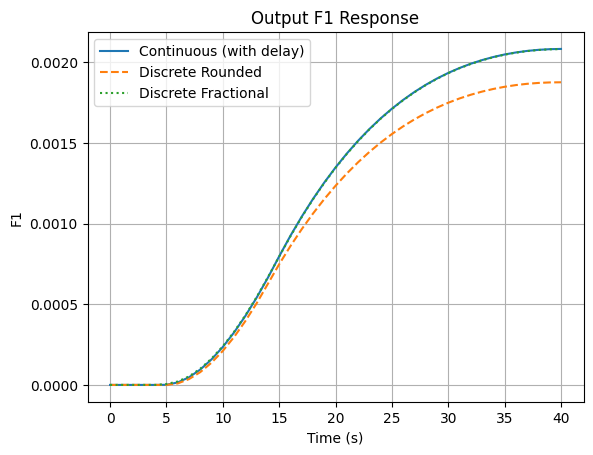

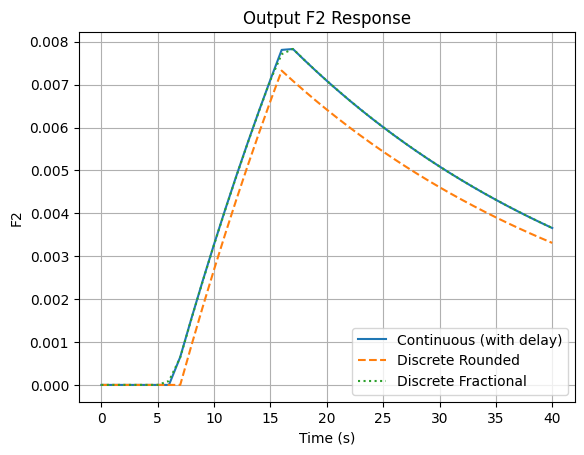

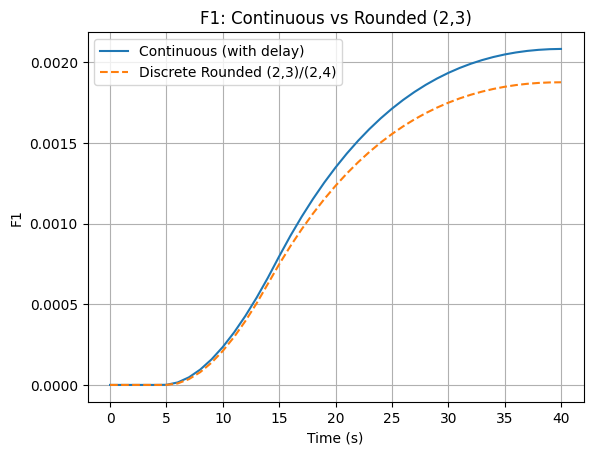

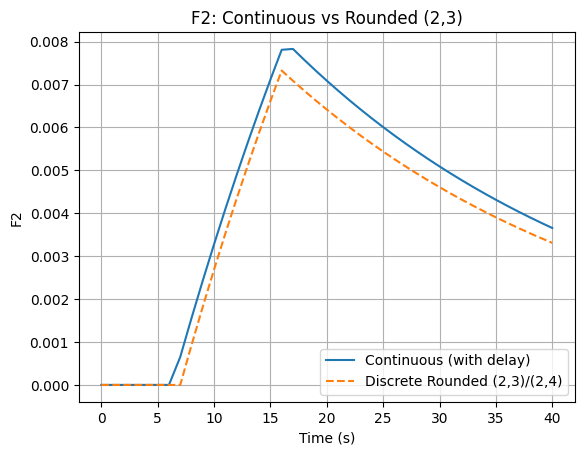

In [7]:
def main():
    # ------------- Parameters (from handout) -------------
    Cp  = 4.217e3        # J/kg-K
    hA  = 8.0e3          # W/K
    hlv = 850.0e3        # J/kg

    m1 = 1.0             # kg/s (upper branch water flow)
    m2 = 1.0             # kg/s (lower branch water flow)
    Ms = 50.0            # kg per exchanger

    rho = 1000.0         # kg/m^3
    V1  = 1.5e-3         # m^3
    V2  = 2.5e-3         # m^3

    theta = np.array([V1 * rho / m1, V2 * rho / m2])  # input delays [s] = [1.5, 2.5]
    phi   = np.array([2.2, 3.8])                      # output delays [s]

    # Time constants and nondimensional params
    tau1 = Ms / m1; tau2 = Ms / m1; tau3 = Ms / m2; tau4 = Ms / m2
    nu1 = hA / (m1 * Cp);    nu2 = hA / (m2 * Cp)
    kappa1 = nu1 / (1 + nu1); kappa2 = nu2 / (1 + nu2)
    mu = hA / hlv

    # Continuous A,B,C,D
    A = np.array([
        [-(1 + kappa1) / tau1,  1.0 / tau1,              0.0,                0.0],
        [0.0,                   -(1 + kappa1) / tau2,    0.0,                0.0],
        [0.0,                    0.0,                   -(1 + kappa2) / tau3, 1.0 / tau3],
        [0.0,                    0.0,                    0.0,               -(1 + kappa2) / tau4]
    ], dtype=float)

    B = np.array([
        [0.0,         0.0],
        [1.0 / tau2,  0.0],
        [0.0,         0.0],
        [0.0,         1.0 / tau4]
    ], dtype=float)

    C = mu * np.array([[1, 0, 1, 0],
                       [0, 1, 0, 1]], dtype=float)
    D = np.zeros((2, 2))

    # ------------- (a) Discretization (ZOH, T=1s) -------------
    T = 1.0
    Ad, Bd = zoh_discretize(A, B, T)

    # (a)(i) Rounded delays to closest integer multiple
    n_theta = np.array([int(np.rint(theta[0]/T)), int(np.rint(theta[1]/T))])  # => [2, 3]
    n_phi   = np.array([int(np.rint(phi[0]/T)),   int(np.rint(phi[1]/T))])    # => [2, 4]

    # (a)(ii) Fractional input delays
    d1, a1, Bd1_prev, Bd1_curr = fractional_input_Bd(A, B[:, [0]], T, theta[0])
    d2, a2, Bd2_prev, Bd2_curr = fractional_input_Bd(A, B[:, [1]], T, theta[1])








    

    # ------------- (b) Simulation -------------
    t_end = 40.0; N = int(t_end / T) + 1
    t_grid = np.arange(N) * T

    # Inputs (steps): +5°C at 1s for u1; -5°C at 10s for u2
    u = np.zeros((N + 50, 2))
    for k in range(N + 50):
        tt = k * T
        if tt >= 1.0:  u[k, 0] = 5.0
        if tt >= 10.0: u[k, 1] = -5.0

    # -- Discrete simulation: rounded integer delays --
    x_r = np.zeros((N, 4)); y_r = np.zeros((N, 2))
    for k in range(N - 1):
        uk = np.array([u[max(k - n_theta[0], 0), 0],
                       u[max(k - n_theta[1], 0), 1]])
        x_r[k + 1] = Ad @ x_r[k] + Bd @ uk
        y_r[k] = C @ x_r[k]
    y_r[-1] = C @ x_r[-1]
    y_r_meas = apply_integer_output_delay(y_r, n_phi)

    # -- Discrete simulation: explicit fractional input + fractional output --
    x_f = np.zeros((N, 4)); y_f = np.zeros((N, 2))
    for k in range(N - 1):
        u1_k_d   = u[max(k - d1, 0), 0]
        u1_k_dm1 = u[max(k - d1 - 1, 0), 0]
        u2_k_d   = u[max(k - d2, 0), 1]
        u2_k_dm1 = u[max(k - d2 - 1, 0), 1]
        Bu = Bd1_prev @ np.array([[u1_k_dm1]]) + Bd1_curr @ np.array([[u1_k_d]]) + \
             Bd2_prev @ np.array([[u2_k_dm1]]) + Bd2_curr @ np.array([[u2_k_d]])
        x_f[k + 1] = Ad @ x_f[k] + Bu.flatten()
        y_f[k] = C @ x_f[k]
    y_f[-1] = C @ x_f[-1]
    y_f_meas = apply_fractional_output_delay(y_f, phi, T)

    # -- Continuous-time baseline with true delays (Euler integration) --
    dt = 0.005
    Tf = np.arange(0, t_end + dt, dt)
    def u_cont(tt: float) -> np.ndarray:
        return np.array([5.0 if tt >= 1.0 else 0.0,
                         -5.0 if tt >= 10.0 else 0.0])
    x_c = np.zeros((len(Tf), 4)); y_c = np.zeros((len(Tf), 2))
    for i, tt in enumerate(Tf[:-1]):
        u_del = np.array([u_cont(max(tt - theta[0], 0.0))[0],
                          u_cont(max(tt - theta[1], 0.0))[1]])
        dx = A @ x_c[i] + B @ u_del
        x_c[i + 1] = x_c[i] + dx * dt
        y_c[i] = C @ x_c[i]
    y_c[-1] = C @ x_c[-1]

    def delay_ct(y: np.ndarray, phi: np.ndarray, dt: float) -> np.ndarray:
        out = np.zeros_like(y)
        for i in range(y.shape[1]):
            shift = phi[i] / dt
            for k in range(len(y)):
                idx = k - shift
                if idx <= 0:
                    out[k, i] = 0.0
                else:
                    k0 = int(np.floor(idx)); a = idx - k0
                    if k0 + 1 < len(y):
                        out[k, i] = (1 - a) * y[k0, i] + a * y[k0 + 1, i]
                    else:
                        out[k, i] = y[-1, i]
        return out

    y_c_meas = delay_ct(y_c, phi, dt)
    sample_idx = (np.arange(N) / dt).astype(int)
    y_c_sampled = y_c_meas[sample_idx]

    # ------------- (b) Plots -------------
    # F1
    plt.figure()
    plt.plot(t_grid, y_c_sampled[:, 0], label='Continuous (with delay)')
    plt.plot(t_grid, y_r_meas[:, 0], '--', label='Discrete Rounded')
    plt.plot(t_grid, y_f_meas[:, 0], ':', label='Discrete Fractional')
    plt.xlabel('Time (s)'); plt.ylabel('F1')
    plt.title('Output F1 Response')
    plt.legend(); plt.grid(True)
    plt.savefig('heatex_hw7_F1.png', dpi=160, bbox_inches='tight')

    # F2
    plt.figure()
    plt.plot(t_grid, y_c_sampled[:, 1], label='Continuous (with delay)')
    plt.plot(t_grid, y_r_meas[:, 1], '--', label='Discrete Rounded')
    plt.plot(t_grid, y_f_meas[:, 1], ':', label='Discrete Fractional')
    plt.xlabel('Time (s)'); plt.ylabel('F2')
    plt.title('Output F2 Response')
    plt.legend(); plt.grid(True)
    plt.savefig('heatex_hw7_F2.png', dpi=160, bbox_inches='tight')









    # ------------- (c) Errors -------------
    Nerr = 80
    err_round = (avg_rel_err(y_c_sampled[:, 0], y_r_meas[:, 0], Nerr),
                 avg_rel_err(y_c_sampled[:, 1], y_r_meas[:, 1], Nerr))
    err_frac  = (avg_rel_err(y_c_sampled[:, 0], y_f_meas[:, 0], Nerr),
                 avg_rel_err(y_c_sampled[:, 1], y_f_meas[:, 1], Nerr))

    # Also: show pure "rounded closest integer" comparison plots only (optional)
    # Use n_theta=(2,3), n_phi=(2,4) already.
    # Save separate plots for clarity against continuous only:
    plt.figure()
    plt.plot(t_grid, y_c_sampled[:, 0], label='Continuous (with delay)')
    plt.plot(t_grid, y_r_meas[:, 0], '--', label='Discrete Rounded (2,3)/(2,4)')
    plt.xlabel('Time (s)'); plt.ylabel('F1')
    plt.title('F1: Continuous vs Rounded (2,3)')
    plt.legend(); plt.grid(True)
    plt.savefig('heatex_hw7_F1_rounded23.png', dpi=160, bbox_inches='tight')

    plt.figure()
    plt.plot(t_grid, y_c_sampled[:, 1], label='Continuous (with delay)')
    plt.plot(t_grid, y_r_meas[:, 1], '--', label='Discrete Rounded (2,3)/(2,4)')
    plt.xlabel('Time (s)'); plt.ylabel('F2')
    plt.title('F2: Continuous vs Rounded (2,3)')
    plt.legend(); plt.grid(True)
    plt.savefig('heatex_hw7_F2_rounded23.png', dpi=160, bbox_inches='tight')

    # ------------- Print & Save Summary -------------
    np.set_printoptions(precision=6, suppress=True)
    print("Ad =\n", Ad)
    print("\nBd (columns = [T1in, T2in]) =\n", Bd)
    print("\nRounded input delays n_theta =", n_theta, "(samples)")
    print("Rounded output delays n_phi  =", n_phi,   "(samples)")
    print("\nAvg relative % error over N=80 samples:")
    print("  Rounded delays : F1 = %.3f%%, F2 = %.3f%%" % err_round)
    print("  Fractional     : F1 = %.3f%%, F2 = %.3f%%" % err_frac)

    with open('heatex_hw7_summary.txt', 'w', encoding='utf-8') as f:
        f.write("Ad =\n%s\n\n" % Ad)
        f.write("Bd =\n%s\n\n" % Bd)
        f.write("n_theta = %s\n" % n_theta)
        f.write("n_phi   = %s\n" % n_phi)
        f.write("Avg error (rounded)  F1=%.3f%%, F2=%.3f%%\n" % err_round)
        f.write("Avg error (fraction) F1=%.3f%%, F2=%.3f%%\n" % err_frac)

if __name__ == "__main__":
    main()

    